In [3]:
from sf_workingdir_lilly.dmlab.custom_esn_analysis import get_hidden_states_iso_feat
import torch
import numpy as np
import matplotlib.pyplot as plt


In [4]:
time_steps = 70
#[0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.92, 0.95, 0.97, 0.99]
spectral_radius = [ 0.3, 0.5, 0.7, 0.9]
sparsity = [ 0.1, 0.3, 0.5, 0.7]
Hippo_n_feature = 16
Hippo_R = 8
Hippo_L = 64
trial=3  #1
fixed_whh=True
fixed_wih=False

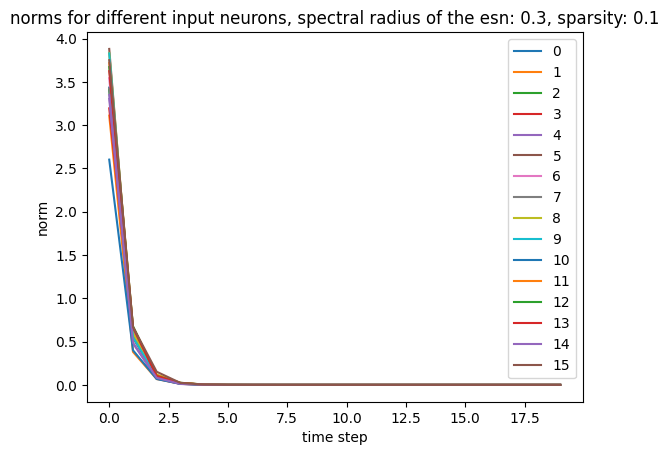

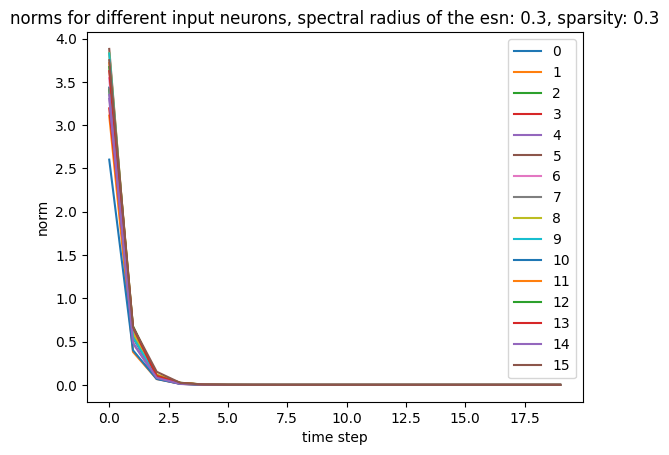

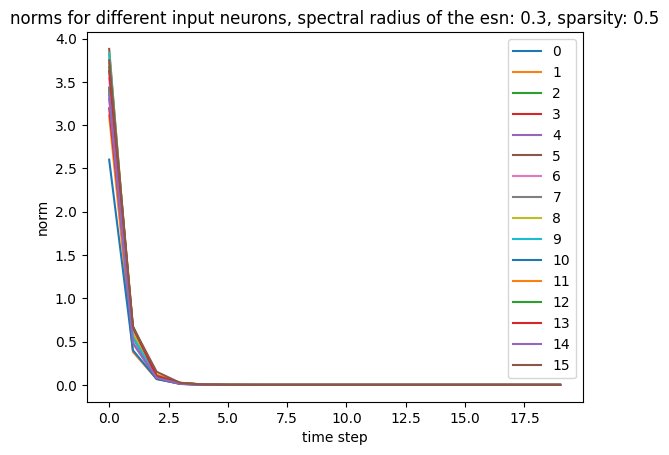

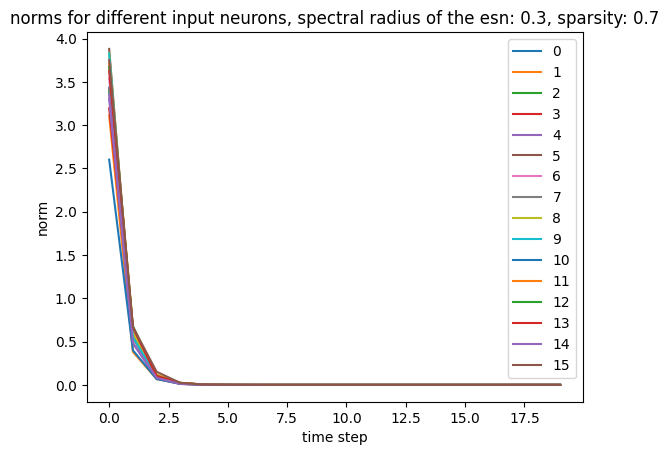

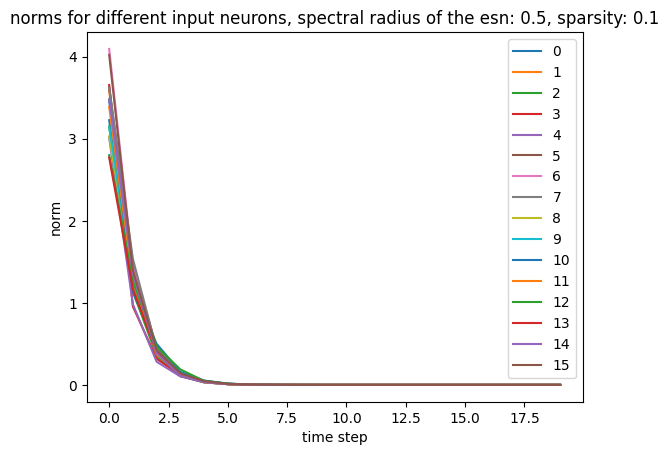

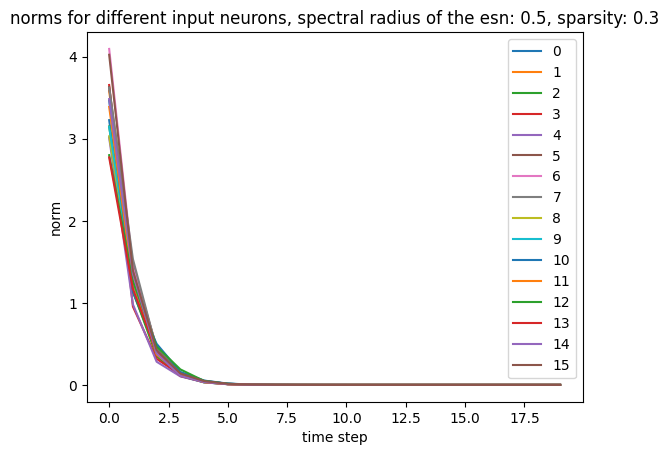

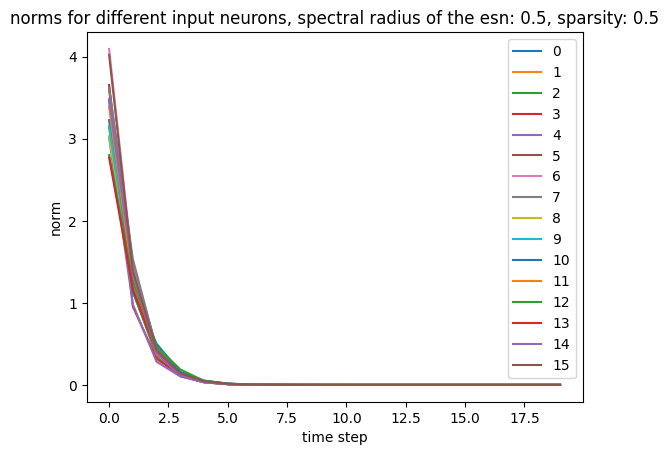

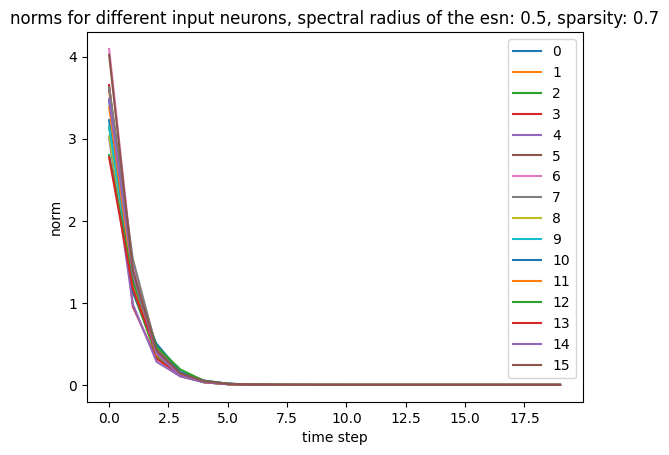

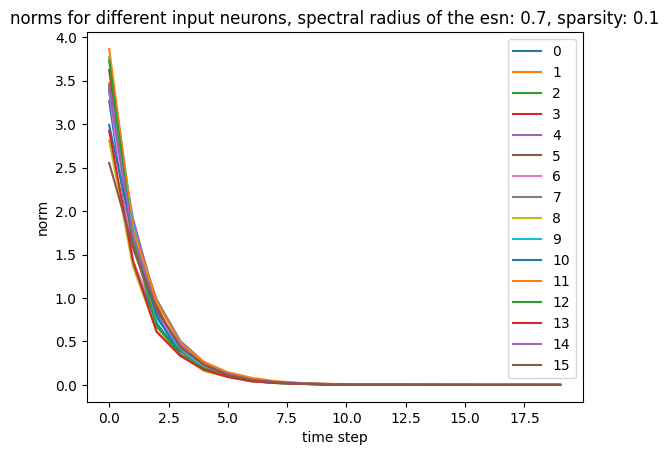

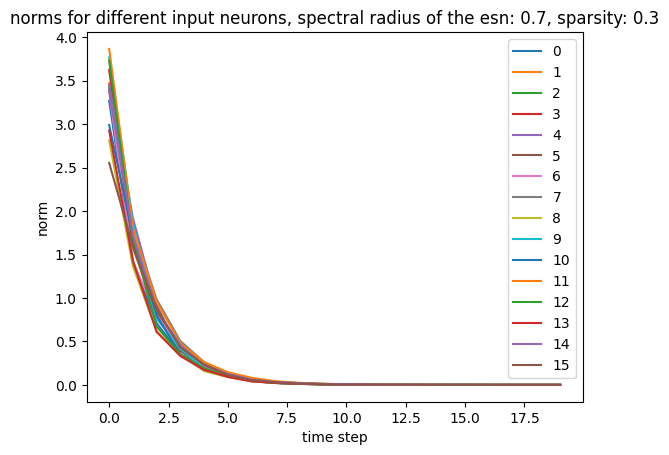

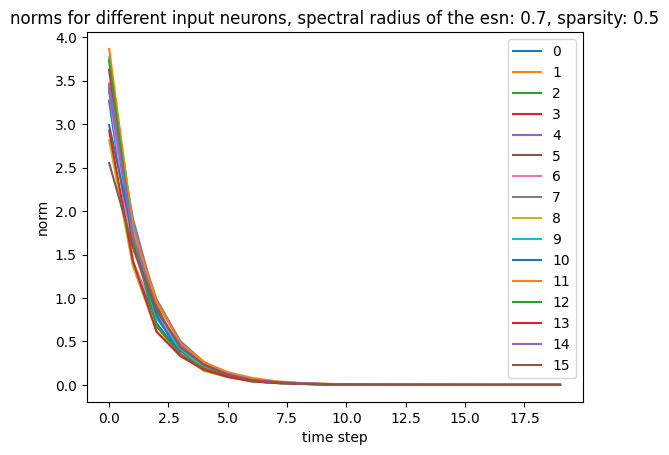

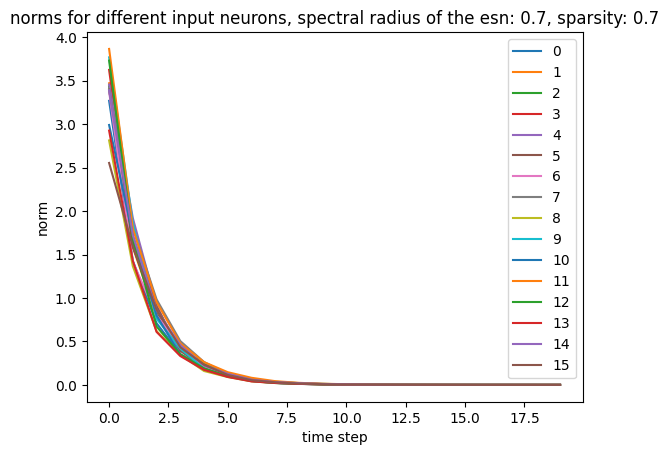

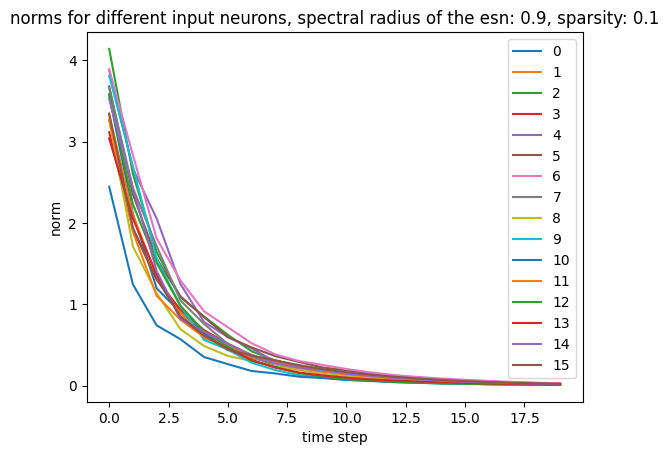

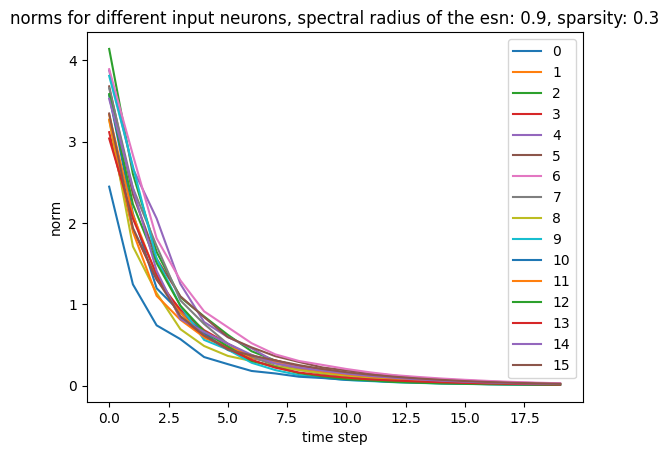

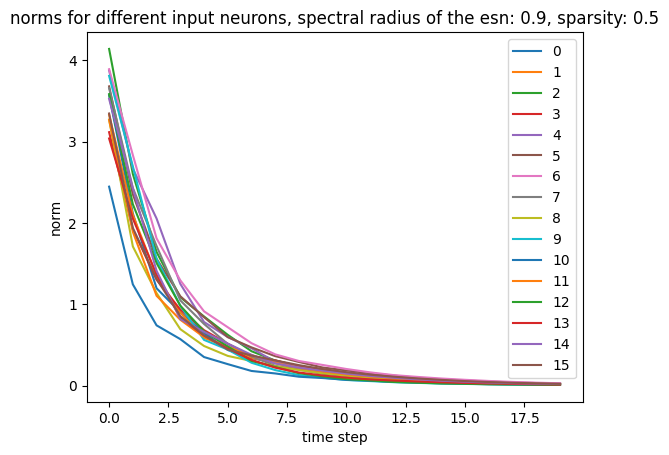

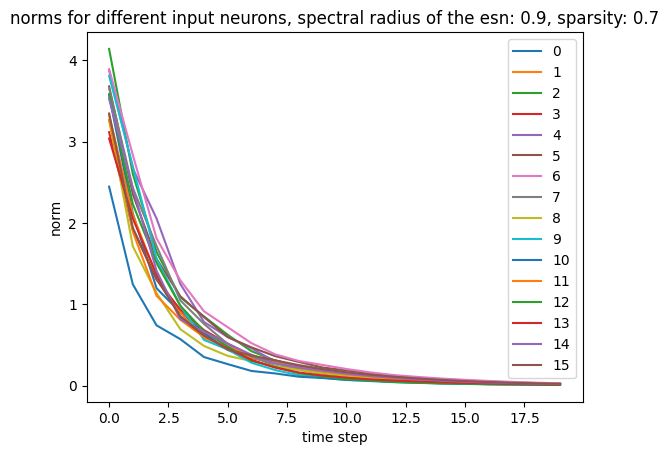

In [5]:
# plot the norms over different input neurons to see for how long the input information stays in the esn

neuron_norms_for_srs = np.zeros((len(spectral_radius), Hippo_n_feature,time_steps))

for sr_i, sr in enumerate(spectral_radius):
    # create a (input_index, time_steps) matrix for each spectral radius - values in the matrix are the norms at this input index at that tiem - and create a plot where the norms are plotted against the time
    #neuron_norms = np.zeros((Hippo_n_feature,time_steps))
    for sparse in sparsity:
        plt.figure()
        for i in range(Hippo_n_feature):
            hs = get_hidden_states_iso_feat(time_steps, sr, Hippo_n_feature, Hippo_R, Hippo_L, trial, fixed_whh, fixed_wih, input_idx=i, sparsity=sparse)  # size: (time_steps, hidden_size)
            norms = hs.norm(dim=1)
            #neuron_norms[i,:] = norms
            neuron_norms_for_srs[sr_i,i,:] = norms
            plt.plot(norms[:20], label=f'{i}')
        
        plt.title(f'norms for different input neurons, spectral radius of the esn: {sr}, sparsity: {sparse}')
        plt.xlabel('time step')
        plt.ylabel('norm')
        plt.legend()
    

     

In [6]:
# define a threshold and see at which time step the norms cross the threshold
# with this you can see at which time step there is basically no more information of the original input in the system

threshold = 0.05

threshold_was_reached = np.zeros((len(spectral_radius), Hippo_n_feature))

for sr_i, sr in enumerate(spectral_radius):
    for i in range(Hippo_n_feature):
        current_norms = neuron_norms_for_srs[sr_i,i,:]
        threshold_idx = np.where(current_norms <= threshold)
        threshold_was_reached[sr_i,i] = threshold_idx[0][0]
    

In [7]:
# at what time step was the threshold reached for each spectral radius - for each different feature that received a non zero input in the beginning

print(threshold_was_reached)
print(threshold_was_reached.mean(axis=1))

[[ 3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.]
 [ 4.  4.  4.  4.  4.  5.  4.  4.  4.  4.  5.  4.  4.  4.  4.  4.]
 [ 7.  7.  7.  7.  7.  6.  6.  7.  6.  6.  7.  7.  6.  6.  7.  7.]
 [16. 15. 16. 16. 15. 17. 17. 14. 15. 12. 12. 15. 12. 14. 15. 16.]]
[ 3.      4.125   6.625  14.8125]


In [8]:
threshold = 0.0001

threshold_was_reached = np.zeros((len(spectral_radius), Hippo_n_feature))

for sr_i, sr in enumerate(spectral_radius):
    for i in range(Hippo_n_feature):
        current_norms = neuron_norms_for_srs[sr_i,i,:]
        threshold_idx = np.where(current_norms <= threshold)
        threshold_was_reached[sr_i,i] = threshold_idx[0][0]

print(threshold_was_reached)
print(threshold_was_reached.mean(axis=1))

[[ 7.  6.  6.  6.  6.  6.  6.  6.  7.  6.  6.  7.  6.  6.  6.  7.]
 [ 9. 10. 10.  9.  9. 10. 10.  9.  9. 10. 10. 10.  9.  9.  9. 10.]
 [17. 17. 18. 17. 17. 17. 17. 17. 17. 17. 17. 18. 17. 16. 18. 17.]
 [44. 43. 43. 43. 43. 44. 45. 42. 42. 40. 40. 43. 40. 41. 43. 44.]]
[ 6.25   9.5   17.125 42.5  ]
